In [48]:
from importlib.metadata import version

pkgs = ["matplotlib",
        "numpy",
        "tiktoken",
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.0.2
tiktoken version: 0.12.0
torch version: 2.10.0+cu128
tensorflow version: 2.19.0


## Unlike the book I am putting all the depedency in one cell for easier imports and object creation

In [50]:
#I am putting everythin in on ceel so it wont hard to manage imports

import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#####################################
# Chapter 2
#####################################


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


#####################################
# Chapter 3
#####################################
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


#####################################
# Chapter 4
#####################################
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx


if __name__ == "__main__":

    GPT_CONFIG_124M = {
        "vocab_size": 50257,     # Vocabulary size
        "context_length": 1024,  # Context length
        "emb_dim": 768,          # Embedding dimension
        "n_heads": 12,           # Number of attention heads
        "n_layers": 12,          # Number of layers
        "drop_rate": 0.1,        # Dropout rate
        "qkv_bias": False        # Query-Key-Value bias
    }

    torch.manual_seed(123)
    model = GPTModel(GPT_CONFIG_124M)
    model.eval()  # disable dropout

    start_context = "Hello, I am a cartoon"

    tokenizer = tiktoken.get_encoding("gpt2")
    encoded = tokenizer.encode(start_context)
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)

    print(f"\n{50*'='}\n{22*' '}IN\n{50*'='}")
    print("\nInput text:", start_context)
    print("Encoded input text:", encoded)
    print("encoded_tensor.shape:", encoded_tensor.shape)

    out = generate_text_simple(
        model=model,
        idx=encoded_tensor,
        max_new_tokens=10,
        context_size=GPT_CONFIG_124M["context_length"]
    )
    decoded_text = tokenizer.decode(out.squeeze(0).tolist())

    print(f"\n\n{50*'='}\n{22*' '}OUT\n{50*'='}")
    print("\nOutput:", out)
    print("Output length:", len(out[0]))
    print("Output text:", decoded_text)


                      IN

Input text: Hello, I am a cartoon
Encoded input text: [15496, 11, 314, 716, 257, 16251]
encoded_tensor.shape: torch.Size([1, 6])


                      OUT

Output: tensor([[15496,    11,   314,   716,   257, 16251, 45500, 17249, 25991,  9390,
         33724, 43231, 47062, 34657, 18631, 49181]])
Output length: 16
Output text: Hello, I am a cartoon philosophieslatedmaybeuto burglary Normandy Compton analogous bore annexed




5.1 Evaluating generative text models

- We start this section with a brief recap of initializing a GPT model using the code from the previous chapter

- Then, we discuss basic evaluation metrics for LLMs

- Lastly, in this section, we apply these evaluation metrics to a training and validation dataset

5.1.1 Using GPT to generate text

- We initialize a GPT model using the code from the previous chapter

In [51]:
import torch

# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays

Modern LLMs also don't use bias vectors in the nn.Linear layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting "qkv_bias": False

We reduce the context length (context_length) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens

This is so that more readers will be able to follow and execute the code examples on their laptop computer

However, please feel free to increase the context_length to 1024 tokens (this would not require any code changes)

We will also load a model with a 1024 context_length later from pretrained weights

Next, we use the generate_text_simple function from the previous chapter to generate text


In addition, we define two convenience functions, text_to_token_ids and token_ids_to_text, for converting between token and text representations that we use throughout this chapter

In [52]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Ganga is a river blue in colour"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Token squeezed for batch:",token_ids.squeeze(0).shape)
print("Token unsqueezed for batch:",token_ids.unsqueeze(0).shape)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Token squeezed for batch: torch.Size([18])
Token unsqueezed for batch: torch.Size([1, 1, 18])
Output text:
 Ganga is a river blue in colourombetermined experimentseland MLS stren Mortgage TT remember gard


- As we can see above, the model does not produce good text because it has not been trained yet
- How do we measure or capture what "good text" is, in a numeric form, to track it during training?
- The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress
- The next chapters on finetuning LLMs will also introduce additional ways to measure model quality

Calculating the text generation loss: cross-entropy and perplexity
Suppose we have an inputs tensor containing the token IDs for 2 training examples (rows)

Corresponding to the inputs, the targets contain the desired token IDs that we want the model to generate

Notice that the targets are the inputs shifted by 1 position, as explained in chapter 2 when we implemented the data loader

In [53]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- Feeding the inputs to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each
- Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary
- Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores

In [54]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


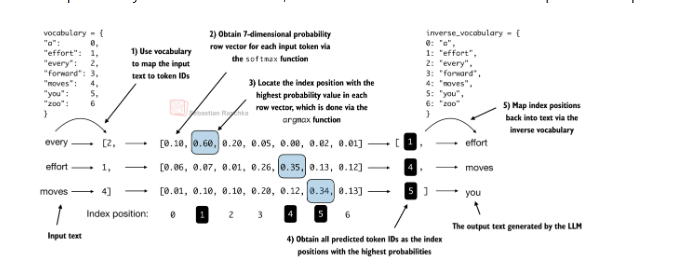

As discussed in the previous chapter, we can apply the argmax function to convert the probability scores into predicted token IDs

- The softmax function above produced a 50,257-dimensional vector for each token; the argmax function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token

- Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [55]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


- If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens:

In [56]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


That's because the model wasn't trained yet

To train the model, we need to know how far it is away from the correct predictions (targets)

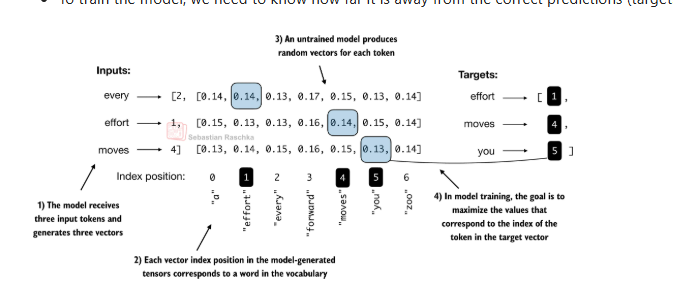

In [9]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


We want to maximize all these values, bringing them close to a probability of 1

- In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself; this is out of the scope of this book, but I have recorded a lecture with more details here: L8.2 Logistic Regression Loss Function

In [10]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- Next, we compute the average log probability:

In [11]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


The goal is to make this average log probability as large as possible by optimizing the model weights

- Due to the log, the largest possible value is 0, and we are currently far away from 0

- In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0

- The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning

In [12]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- PyTorch already implements a cross_entropy function that carries out the previous steps

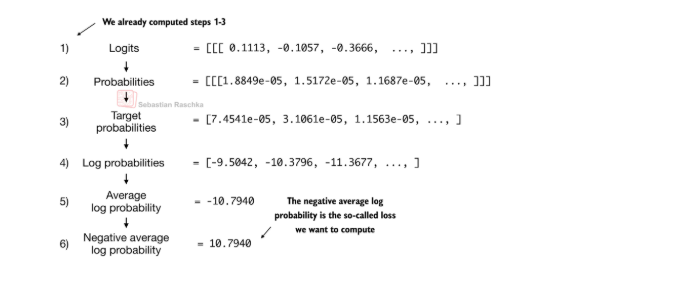

- Before we apply the cross_entropy function, let's check the shape of the logits and targets

In [57]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- For the cross_entropy function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [58]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize

- The cross_entropy function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximize

In [59]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


- The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens)

- In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset

- Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

## 5.1.3 Calculating the training and validation set losses

We will now use wikipedia

The reasons are:

- You can run the code examples in a few minutes on a laptop computer without a suitable GPU

- The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes.

- We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size
For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens

- At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately $30

So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * $30 = $690,000
Below, we use the same dataset we used in chapter 2

### Download WikiText-103 Dataset

I will download the WikiText-103 dataset, which is suitable for your requirement of a large text document (at least 100 MB) from Wikipedia. This dataset is a popular benchmark for language modeling and is derived from Wikipedia articles.

### Extract the Dataset

### Download and Prepare Cornell Movie-Dialogs Corpus

I will now download the Cornell Movie-Dialogs Corpus, extract it, and consolidate the dialogues into a single text file. This dataset is a popular choice for dialogue-based language models.

In [60]:
import requests
import zipfile
import os

url = "http://www.cs.cornell.edu/~cristian/data/cornell_movie_dialogs_corpus.zip"
output_zip_filename = "cornell_movie_dialogs_corpus.zip"
output_text_filename = "movie_dialogues.txt"

# 1. Download the dataset
print(f"Downloading {output_zip_filename}...")
response = requests.get(url, stream=True)
response.raise_for_status() # Raise an exception for HTTP errors

with open(output_zip_filename, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print("Download complete.")

# 2. Extract the dataset
print(f"Extracting {output_zip_filename}...")
with zipfile.ZipFile(output_zip_filename, 'r') as zip_ref:
    zip_ref.extractall(".")
print("Extraction complete.")

# 3. Consolidate dialogues into a single text file
print(f"Consolidating dialogues into {output_text_filename}...")
movies_dir = "cornell movie-dialogs corpus"
dialogues_file = os.path.join(movies_dir, "movie_lines.txt")

lines = {}
with open(dialogues_file, 'r', encoding='iso-8859-1') as f:
    for line in f:
        parts = line.split(' +++$+++ ')
        if len(parts) == 5:
            line_id = parts[0]
            text = parts[4].strip()
            lines[line_id] = text

conversations_file = os.path.join(movies_dir, "movie_conversations.txt")

with open(output_text_filename, 'w', encoding='utf-8') as outfile:
    with open(conversations_file, 'r', encoding='iso-8859-1') as f:
        for line in f:
            parts = line.split(' +++$+++ ')
            if len(parts) == 4:
                line_ids_str = parts[3].strip()
                line_ids = eval(line_ids_str) # Safely evaluate string to list
                for line_id in line_ids:
                    if line_id in lines:
                        outfile.write(lines[line_id] + '\n')
print("Dialogues consolidated.")

# 4. Verify the size of the created file
file_size_bytes = os.path.getsize(output_text_filename)
file_size_mb = file_size_bytes / (1024 * 1024)
print(f"Created '{output_text_filename}' with actual size: {file_size_mb:.2f} MB")

# Check if the file meets the 100 MB requirement (adjust if needed for this dataset)
if file_size_mb >= 100:
    print("The new file meets the minimum size requirement of 100 MB.")
else:
    print(f"Warning: The new file is less than 100 MB ({file_size_mb:.2f} MB). This might be expected for this dataset or we may need to combine more data.")

# Assign the new text data to the 'text_data' variable
with open(output_text_filename, 'r', encoding='utf-8') as f:
    text_data = f.read()

print("First 500 characters of the new text_data:")
print(text_data[:500])



Download complete.
Extracting cornell_movie_dialogs_corpus.zip...
Extraction complete.
Consolidating dialogues into movie_dialogues.txt...
Dialogues consolidated.
Created 'movie_dialogues.txt' with actual size: 16.36 MB
First 500 characters of the new text_data:
Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.
Well, I thought we'd start with pronunciation, if that's okay with you.
Not the hacking and gagging and spitting part.  Please.
Okay... then how 'bout we try out some French cuisine.  Saturday?  Night?
You're asking me out.  That's so cute. What's your name again?
Forget it.
No, no, it's my fault -- we didn't have a proper introduction ---
Cameron.
The thing is, C


In [61]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 17146578
Tokens: 4790862


### Create a 100 MB Text File

Now I will create a new text file containing exactly 100 MB of data from the extracted `wiki.train.tokens` file.

In [62]:
# First 99 characters
print(text_data[:99])

Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous pub


In [63]:
# Last 99 characters
print(text_data[-99:])

seen?
So far only their scouts. But we have had reports of a small Impi farther north, over there.



In [64]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 17146578
Tokens: 4790862


## We could see we have 23 Million Tokens

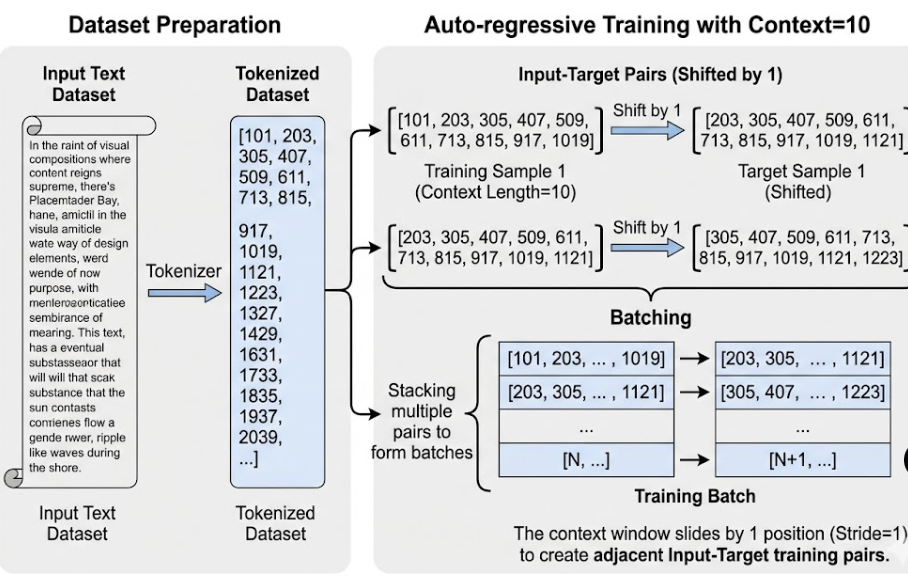

In [65]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=16,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=16,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [66]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with

Llama 2 7B was trained with a batch size of 1024, for example

An optional check that the data was loaded correctly:

In [67]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("Length of train:",len(train_loader))
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)
print("Length of validation:",len(val_loader))

Train loader:
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 256]) torch.Size([16, 256])
torch.Size([16, 25

In [68]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4304896
Validation tokens: 481792
All tokens: 4786688


- Next, we implement a utility function to calculate the cross-entropy loss of a given batch
- In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [69]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code

- Via the device setting, we ensure that the data is loaded onto the same device as the LLM model

In [70]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


# model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


# torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

# with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
#     train_loss = calc_loss_loader(train_loader, model, device)
#     val_loss = calc_loss_loader(val_loader, model, device)

# print("Training loss:", train_loss)
# print("Validation loss:", val_loss)


Using cuda device.


In [71]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [28]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 3
# Adjust eval_freq to evaluate once per epoch
# eval_freq = len(train_loader) # This is better for epoch-wise evaluation

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=len(train_loader), eval_iter=1,
    start_context="You think you are beautiful?", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.340, Val loss 9.235
You think you are beautiful? I'm not sure you're not a lot of people. I'm sorry. I'm not sure you're not. I'm not sure. I'm not sure you're not going to be a lot of people. 
Ep 2 (Step 001051): Train loss 4.515, Val loss 4.606
You think you are beautiful? I'm not sure. I'm not sure you're a good man. I'm not sure you're a good man. I'm not a man. I'm not a man. I'm not a man. 
Ep 3 (Step 002102): Train loss 4.068, Val loss 4.357
You think you are beautiful? I don't know. I don't know. I don't know. I don't know. I don't know. I don't know. I don't know. I don't know. I


## We will now plot the loss function

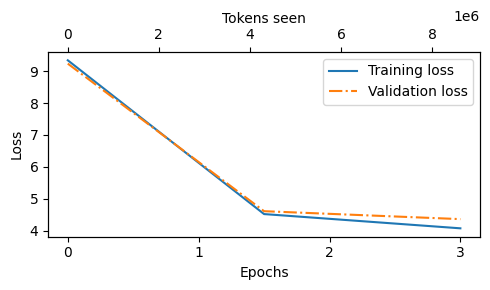

In [46]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Saving the Model to local drive

In [72]:
model_path = "gpt_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to gpt_model.pth


## Load model from cpu and load for inference

In [73]:
model_path = "gpt_model.pth"

# Instantiate a new model with the same configuration
# GPT_CONFIG_124M should be available in the notebook state
loaded_model = GPTModel(GPT_CONFIG_124M)

# Load the state dictionary
loaded_model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# Set the model to evaluation mode
loaded_model.eval()

# Move the model to CPU
device_cpu = torch.device("cpu")
loaded_model.to(device_cpu)

print(f"Model loaded from {model_path} to {device_cpu}.")

Model loaded from gpt_model.pth to cpu.


## We will use the loaded model for inference

In [74]:
# You can now use 'loaded_model' for inference on CPU
# For example, to generate text:
start_context_loaded = "I stole a car"

tokenizer = tiktoken.get_encoding("gpt2")
encoded_loaded = text_to_token_ids(start_context_loaded, tokenizer).to(device_cpu)

output_loaded = generate_text_simple(
    model=loaded_model,
    idx=encoded_loaded,
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"]
)
decoded_text_loaded = token_ids_to_text(output_loaded, tokenizer)

print("\nGenerated text with loaded model:")
print(decoded_text_loaded)


Generated text with loaded model:
I stole a car.
I don't know.
I don't know.
I don't know.



## We will now see how to implement temperature in sampling

In [77]:
def generate_text_with_temperature(model, idx, max_new_tokens, context_size, temperature=1.0):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):
        # Crop current context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        logits = logits[:, -1, :]

        # Apply temperature
        if temperature == 0.0:
            # If temperature is 0, use argmax for deterministic sampling
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # Scale logits by temperature
            logits_scaled = logits / temperature
            # Apply softmax to get probabilities
            probs = torch.softmax(logits_scaled, dim=-1)
            # Sample from the multinomial distribution
            idx_next = torch.multinomial(probs, num_samples=1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# Example usage with temperature
start_context_temp = "I stole a car"
tokenizer = tiktoken.get_encoding("gpt2")
encoded_temp = text_to_token_ids(start_context_temp, tokenizer).to(device_cpu)

# Generate with a low temperature (more deterministic)
output_low_temp = generate_text_with_temperature(
    model=loaded_model,
    idx=encoded_temp,
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=0.5
)
decoded_text_low_temp = token_ids_to_text(output_low_temp, tokenizer)
print("\nGenerated text with low temperature (0.5):")
print(decoded_text_low_temp)

# Generate with a higher temperature (more random)
output_high_temp = generate_text_with_temperature(
    model=loaded_model,
    idx=encoded_temp,
    max_new_tokens=20,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=0.001
)
decoded_text_high_temp = token_ids_to_text(output_high_temp, tokenizer)
print("\nGenerated text with high temperature (0.001):")
print(decoded_text_high_temp)


Generated text with low temperature (0.5):
I stole a car and I found a girl in a room.
I don't know.
You know, I

Generated text with high temperature (0.001):
I stole a car.
I don't know.
I don't know.
I don't know.

